# Orbital Convergence Testing (Refactored)

This notebook refactors the convergence workflow into reusable functions and runs the analysis for both `exponential_oblate_halo` and `ibata2024halo`.

In [1]:
import datetime
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from astropy import units as u
from astropy import constants as const
import tstrippy

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
})

In [2]:
def make_a4_three_panel_layout(
    width_ratios=(1.0, 1/20, 3/4),
    cbar_right_gap_ratio=1/3,
    page_width_in=8.27,
    margin_left_in=1.0,
    margin_right_in=1.0,
    fig_height_in=3.0,
    dpi=300,
):
    usable_width = page_width_in - margin_left_in - margin_right_in
    if usable_width <= 0:
        raise ValueError("Margins are too large for the page width")

    fig = plt.figure(figsize=(usable_width, fig_height_in), dpi=dpi)
    left = margin_left_in / page_width_in
    right = 1.0 - (margin_right_in / page_width_in)

    left_ratio, cbar_ratio, right_ratio = width_ratios
    gs = fig.add_gridspec(
        nrows=1,
        ncols=4,
        width_ratios=[left_ratio, cbar_ratio, cbar_right_gap_ratio, right_ratio],
        left=left,
        right=right,
        bottom=0.12,
        top=0.95,
        wspace=0.0,
    )

    ax_left = fig.add_subplot(gs[0, 0])
    ax_cbar = fig.add_subplot(gs[0, 1])
    ax_right = fig.add_subplot(gs[0, 3])

    ax_cbar.yaxis.set_ticks_position("right")
    ax_cbar.yaxis.set_label_position("right")
    ax_right.yaxis.tick_right()
    ax_right.yaxis.set_label_position("right")

    return fig, ax_left, ax_cbar, ax_right

In [3]:
def density_exponential_oblate(rho0, s0, q, x, y, z):
    R = np.sqrt(x**2 + y**2)
    return rho0 * np.exp(-(1.0 / s0) * np.sqrt(R**2 + (z / q)**2))


def density_ibata2024(rho0, r0, rt, q, gamma, beta, x, y, z):
    R = np.sqrt(x**2 + y**2)
    s = np.sqrt(R**2 + (z / q)**2)
    x_s = np.maximum(s / r0, 1.0e-12)
    return rho0 * x_s**(-gamma) * (1.0 + x_s)**(gamma - beta) * np.exp(-(s / rt)**2)


def make_density_map(density_callable, density_args, results_ref, Rmax, npoints=120):
    zmax = np.max(np.abs(results_ref[2, :]))
    Rs = np.linspace(-Rmax, Rmax, npoints)
    zs = np.linspace(-zmax, zmax, npoints)
    RS, ZS = np.meshgrid(Rs, zs, indexing="xy")
    RHO = density_callable(*density_args, RS, np.zeros_like(RS), ZS)
    return RS, ZS, RHO

In [4]:
def gravitational_constant_kpc_kms_msun():
    unitV = u.km / u.s
    unitG = unitV**2 * (u.kpc / u.Msun)
    return const.G.to(unitG).value


def build_initial_conditions(potential_func, params, radius, eccen=0.4, theta=np.pi/4, phi=-np.pi/4, polar_mix=0.5):
    rvec, vvec, azimuth_hat, meridional_hat = tstrippy.code.orbits.apoapsis_shot(
        potential=potential_func,
        params=params,
        radius=radius,
        eccen=eccen,
        theta=theta,
        phi=phi,
        polar_mix=polar_mix,
        getVecs=True,
    )
    initial_kinematics = [[rvec[0]], [rvec[1]], [rvec[2]], [vvec[0]], [vvec[1]], [vvec[2]]]
    return initial_kinematics, (rvec, vvec, azimuth_hat, meridional_hat)


def build_integration_params(Tchar, nstep_factor=1e4, total_time_factor=20.0):
    dt = Tchar / nstep_factor
    integration_time = total_time_factor * Tchar
    nsteps = int(integration_time / dt)
    integration_time = nsteps * dt
    return [0.0, dt, nsteps], integration_time

In [5]:
def run_convergence_analysis(
    static_halo_name,
    static_halo_params,
    initial_kinematics,
    integration_params,
    lmaxes,
    rgrid,
    G,
):
    nsteps = int(integration_params[2])
    results = np.zeros((lmaxes.shape[0], 6, nsteps + 1))
    comptimes = np.zeros(lmaxes.shape[0], dtype=float)

    for i, lmax in enumerate(lmaxes):
        t0 = datetime.datetime.now()

        tstrippy.integrator.deallocate()
        tstrippy.integrator.clearaxisymmetricbasisexpansion()
        tstrippy.integrator.initaxisymmetricbasisexpansion(G, int(lmax), rgrid)
        tstrippy.integrator.setinitialkinematics(*initial_kinematics)
        tstrippy.integrator.setintegrationparameters(*integration_params)
        tstrippy.integrator.setstaticgalaxy(static_halo_name, static_halo_params)

        xt, yt, zt, vxt, vyt, vzt = tstrippy.integrator.leapfrogintime(nsteps, 1)
        xt, yt, zt, vxt, vyt, vzt = xt[0], yt[0], zt[0], vxt[0], vyt[0], vzt[0]
        timestamps = tstrippy.integrator.timestamps.copy()

        results[i, 0, :] = xt
        results[i, 1, :] = yt
        results[i, 2, :] = zt
        results[i, 3, :] = vxt
        results[i, 4, :] = vyt
        results[i, 5, :] = vzt

        comptimes[i] = (datetime.datetime.now() - t0).total_seconds()

    R = np.sqrt(np.sum(results[:, 0:2, :]**2, axis=1))

    rms = np.zeros((lmaxes.shape[0] - 1, nsteps + 1))
    ref = results[-1]
    denom = np.maximum(np.abs(ref), 1.0e-30)
    for i in range(lmaxes.shape[0] - 1):
        diff = results[i] - ref
        rms[i] = np.sqrt(np.sum((diff**2) / denom, axis=0))

    return results, timestamps, R, rms, comptimes

In [24]:
def plot_convergence_panels(
    results, timestamps, lmaxes, R, rms,
    density_callable, density_args, rho_ref, q_ref,
    title_left, title_right,
):
    nskip = max(1, len(lmaxes) // 10)
    signal_index = -1

    peaks, _ = signal.find_peaks(rms[signal_index], distance=20)
    npeaks = 10
    if peaks.size > 0:
        peaks = peaks[np.argsort(rms[signal_index][peaks])[::-1][:npeaks]]

    RS, ZS, RHO = make_density_map(
        density_callable=density_callable,
        density_args=density_args,
        results_ref=results[-1],
        Rmax=R.max(),
    )

    cmap = plt.get_cmap("rainbow")
    norm = plt.cm.colors.Normalize(vmin=lmaxes.min(), vmax=lmaxes.max())
    colors = [cmap(norm(val)) for val in lmaxes]

    fig, ax_left, ax_cbar, ax_right = make_a4_three_panel_layout()

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, cax=ax_cbar)
    cbar.set_label(r"$\ell_{\rm max}$")

    for i in range(len(lmaxes) - 1):
        ax_left.plot(timestamps, rms[i], color=colors[i], linewidth=1.2)
    ax_left.set_yscale("log")
    ax_left.set_xlim(timestamps[0], timestamps[-1])
    ax_left.set_xlabel(r"Time [s kpc/km]")
    ax_left.set_ylabel(r"$\mathrm{RMS}$")
    ax_left.set_title(title_left)

    if peaks.size > 0:
        ax_left.scatter(timestamps[peaks], rms[signal_index][peaks], color=colors[-1], s=30, zorder=10)

    ax_right.set_aspect("equal")
    ax_right.set_xlabel(r"$R$ [kpc]")
    ax_right.set_ylabel(r"$z$ [kpc]")

    cmap_density = plt.get_cmap("magma")
    log_norm = plt.cm.colors.LogNorm(vmin=max(1.0e-1 * rho_ref, 1.0e-20), vmax=max(rho_ref, 1.0e-20))
    ax_right.pcolormesh(RS, ZS, RHO, shading="auto", cmap=cmap_density, norm=log_norm)

    for i in range(0, len(lmaxes), nskip):
        ax_right.plot(results[i, 0, :], results[i, 2, :], color=colors[i], linestyle=":", linewidth=1.0)
    ax_right.plot(results[-1, 0, :], results[-1, 2, :], color=colors[-1], linewidth=2.0, zorder=10)

    if peaks.size > 0:
        ax_right.scatter(results[-1, 0, peaks], results[-1, 2, peaks], color=colors[-1], s=30, zorder=20)

    ax_right.set_title(f"{title_right} (q={q_ref:.3f})")

    return fig

## Exponential Oblate Halo

Done exponential halo: 24 models


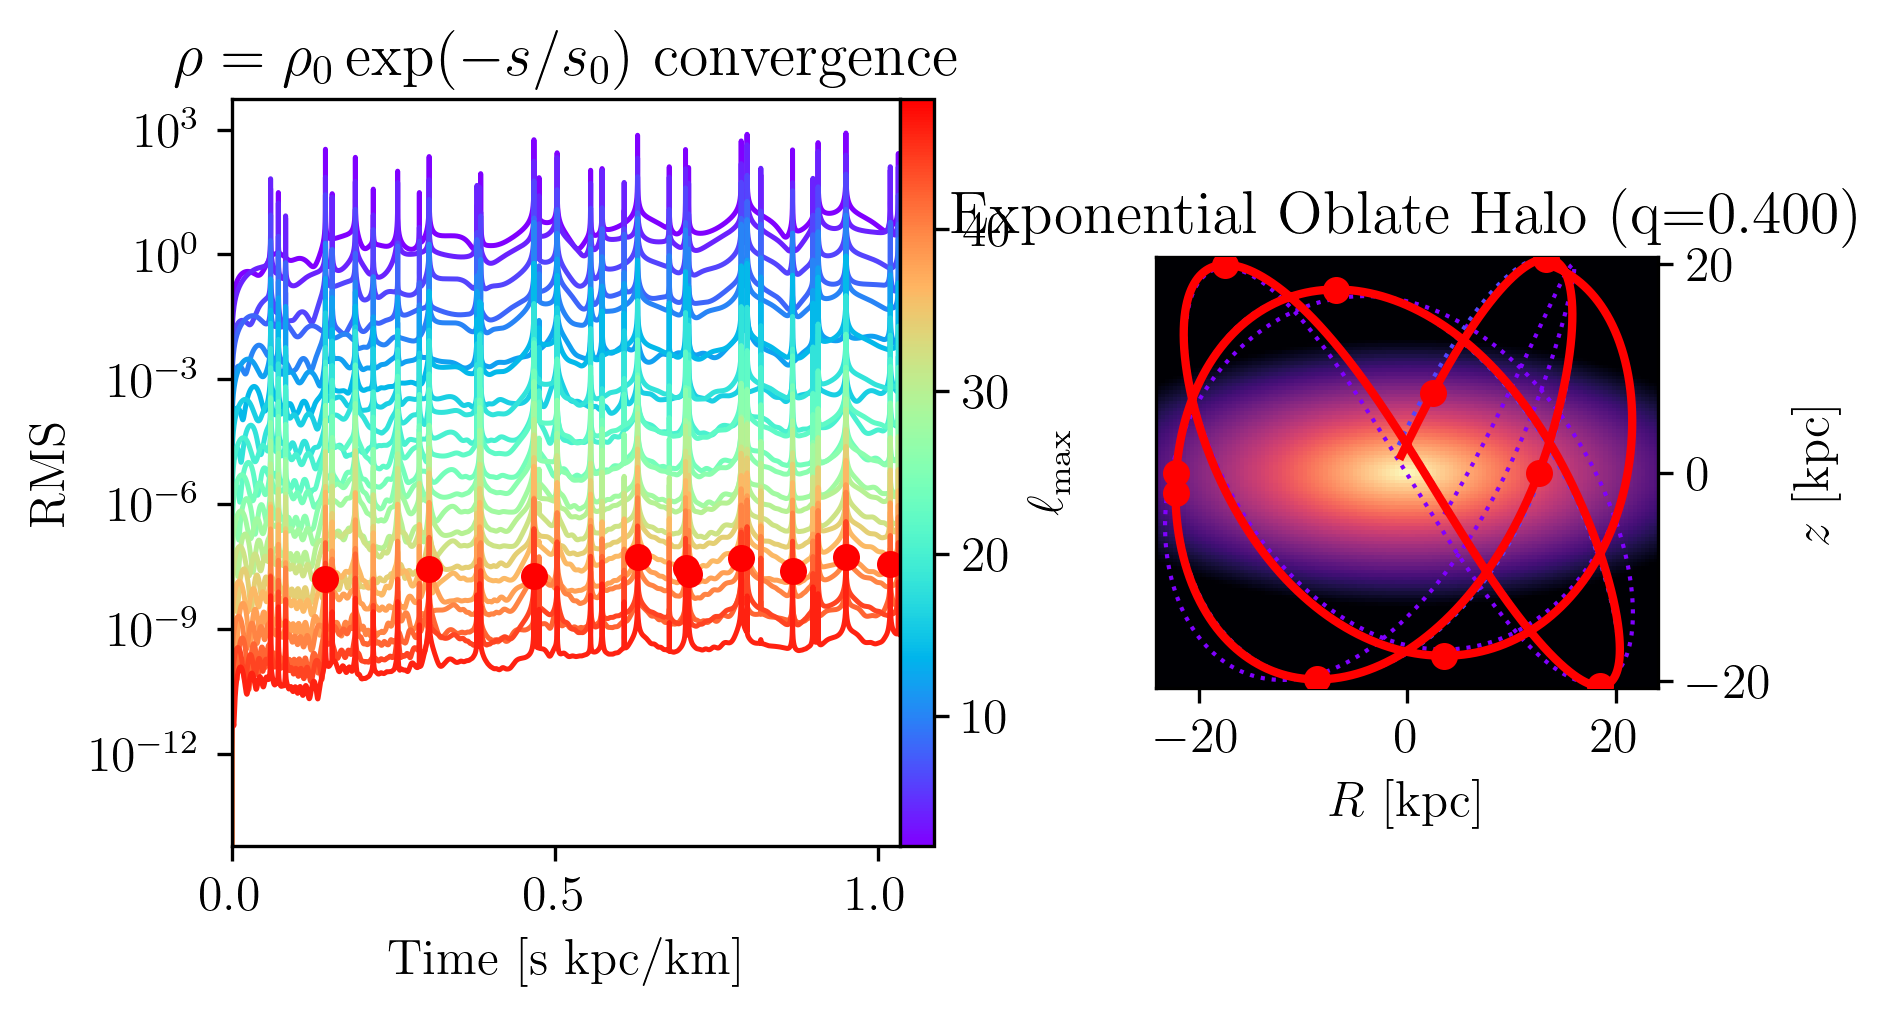

In [25]:
G = gravitational_constant_kpc_kms_msun()

# Exponential halo parameters
q_exp = 0.4
s0_exp = 14.0
Mtot_exp = 1.0e12
rho0_exp = 3.0 * Mtot_exp / (4.0 * np.pi * s0_exp**3)

params_exp = [G, rho0_exp, s0_exp, q_exp]
halo_name_exp = "exponential_oblate_halo"
potential_exp = tstrippy.potentials.exponential_oblate_halo

Tchar_exp = 1.0 / np.sqrt(G * rho0_exp)
integration_params_exp, integration_time_exp = build_integration_params(Tchar_exp)

initial_kinematics_exp, _ = build_initial_conditions(
    potential_func=potential_exp,
    params=params_exp,
    radius=2.0 * s0_exp,
)

lmaxes_exp = np.arange(2, 50, 2)
rgrid_exp = np.logspace(-4, 3, 100)

results_exp, timestamps_exp, R_exp, rms_exp, comptimes_exp = run_convergence_analysis(
    static_halo_name=halo_name_exp,
    static_halo_params=params_exp,
    initial_kinematics=initial_kinematics_exp,
    integration_params=integration_params_exp,
    lmaxes=lmaxes_exp,
    rgrid=rgrid_exp,
    G=G,
)

fig_exp = plot_convergence_panels(
    results=results_exp,
    timestamps=timestamps_exp,
    lmaxes=lmaxes_exp,
    R=R_exp,
    rms=rms_exp,
    density_callable=density_exponential_oblate,
    density_args=(rho0_exp, s0_exp, q_exp),
    rho_ref=rho0_exp,
    q_ref=q_exp,
    title_left=r"$\rho=\rho_0\exp(-s/s_0)$ convergence",
    title_right="Exponential Oblate Halo",
)

print(f"Done exponential halo: {len(lmaxes_exp)} models")
plt.show()

## Ibata 2024 Halo

In [26]:
# Ibata et al. 2024 parameters
rho0_ib = 11.4 * (1e3)**3
r0_ib = 21.4
rt_ib = 1000.0
q_ib = 0.735
gamma_ib = 1.03
beta_ib = 3.0

params_ib = [G, rho0_ib, r0_ib, rt_ib, q_ib, gamma_ib, beta_ib]
halo_name_ib = "ibata2024halo"
potential_ib = tstrippy.potentials.ibata2024halo

In [27]:
Tchar_ib = 1.0 / np.sqrt(G * rho0_ib)
integration_params_ib, integration_time_ib = build_integration_params(Tchar_ib)

In [28]:
initial_kinematics_ib, _ = build_initial_conditions(
    potential_func=potential_ib,
    params=params_ib,
    radius=2.0 * r0_ib,
)

lmaxes_ib = np.arange(2, 50, 2)
rgrid_ib = np.logspace(-4, 3, 100)

In [29]:
results_ib, timestamps_ib, R_ib, rms_ib, comptimes_ib = run_convergence_analysis(
    static_halo_name=halo_name_ib,
    static_halo_params=params_ib,
    initial_kinematics=initial_kinematics_ib,
    integration_params=integration_params_ib,
    lmaxes=lmaxes_ib,
    rgrid=rgrid_ib,
    G=G,
)

Done Ibata halo: 24 models


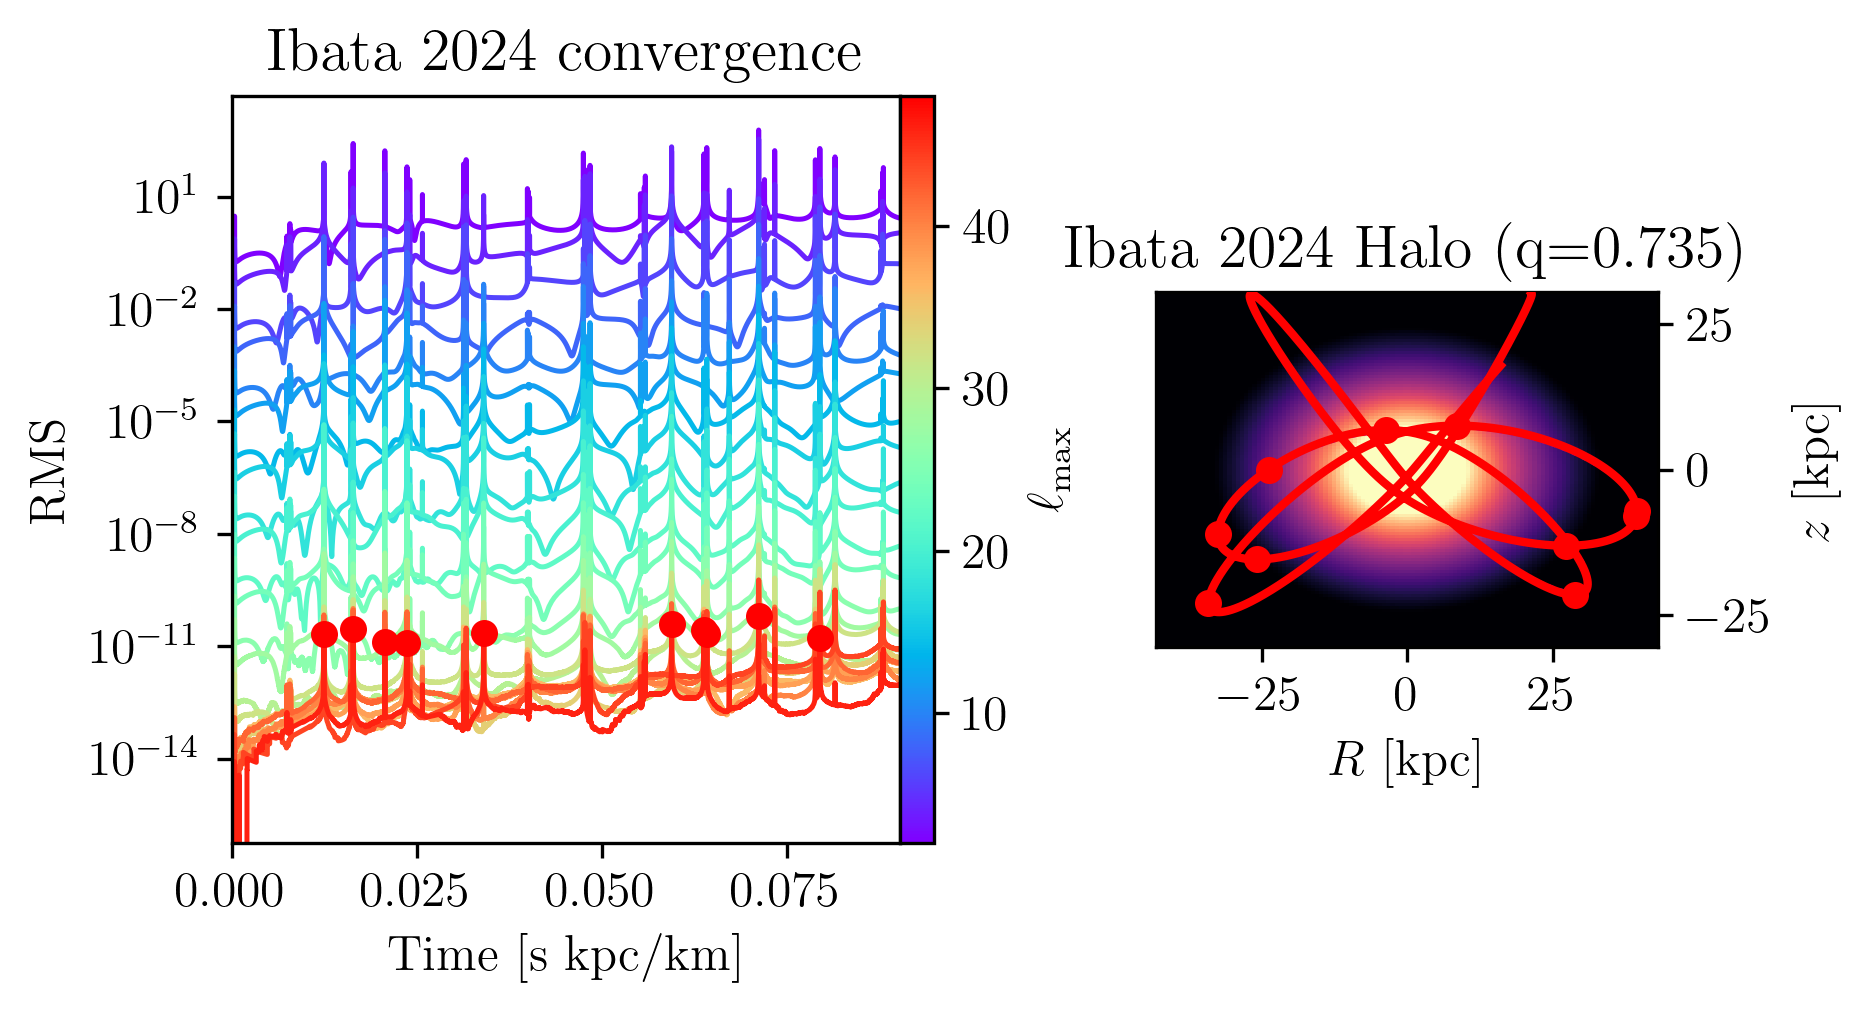

In [30]:


fig_ib = plot_convergence_panels(
    results=results_ib,
    timestamps=timestamps_ib,
    lmaxes=lmaxes_ib,
    R=R_ib,
    rms=rms_ib,
    density_callable=density_ibata2024,
    density_args=(rho0_ib, r0_ib, rt_ib, q_ib, gamma_ib, beta_ib),
    rho_ref=rho0_ib,
    q_ref=q_ib,
    title_left=r"Ibata 2024 convergence",
    title_right="Ibata 2024 Halo",
)

print(f"Done Ibata halo: {len(lmaxes_ib)} models")
plt.show()

In [32]:

np.mean(metric_ib)

np.float64(1.882437049364273e-08)

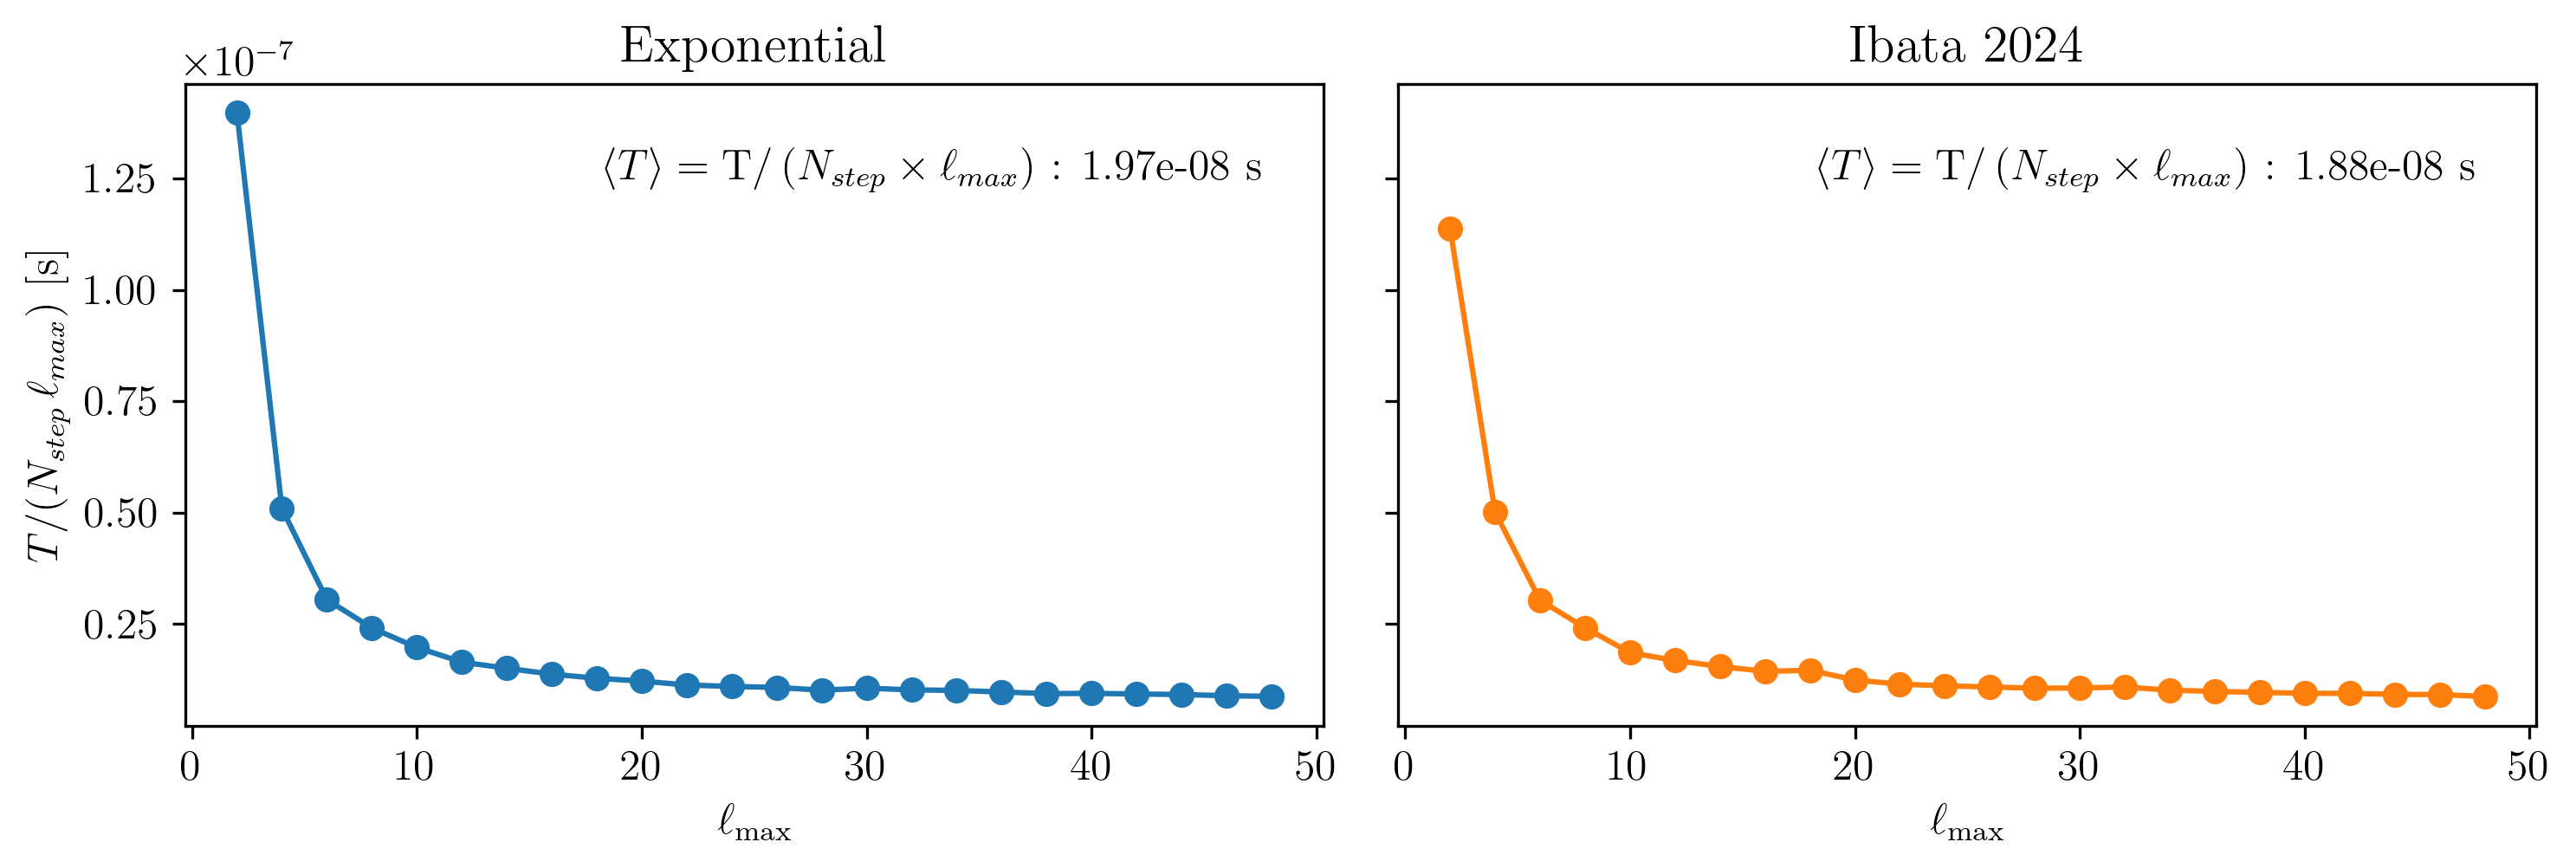

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), dpi=300, sharey=True)

metric_exp = comptimes_exp / (integration_params_exp[2] * lmaxes_exp)
metric_ib = comptimes_ib / (integration_params_ib[2] * lmaxes_ib)

axes[0].plot(lmaxes_exp, metric_exp, marker="o")
axes[0].set_title("Exponential")
axes[0].set_xlabel(r"$\ell_{\rm max}$")
axes[0].set_ylabel(r"$T/(N_{step}\,\ell_{max})$ [s]")

axes[1].plot(lmaxes_ib, metric_ib, marker="o", color="tab:orange")
axes[1].set_title("Ibata 2024")
axes[1].set_xlabel(r"$\ell_{\rm max}$")
axes[0].text(
    0.95, 0.9,
    r"$\left<T\right> = \mathrm{T} / \left( N_{step}\times \ell_{max}\right)$"+" : {:9.2e} s ".format(metric_exp.mean()),
    transform=axes[0].transAxes,
    ha="right",
    va="top",
)
axes[1].text(
    0.95, 0.9,
    r"$\left<T\right> = \mathrm{T} / \left( N_{step}\times \ell_{max}\right)$"+" : {:9.2e} s ".format(metric_ib.mean()),
    transform=axes[1].transAxes,
    ha="right",
    va="top",
)
plt.tight_layout()
plt.show()